<a href="https://colab.research.google.com/github/Godstouch/GNN-Student-Risk-Prediction-/blob/main/GNNExplainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch-geometric


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch_geometric.nn import GATConv
from torch_geometric.explain import Explainer, GNNExplainer

from sklearn.metrics import accuracy_score, f1_score, classification_report

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA available: False


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch_geometric.nn import GATConv
from torch_geometric.explain import Explainer, GNNExplainer

from sklearn.metrics import accuracy_score, f1_score, classification_report

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA available: False


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_graph = "/content/drive/MyDrive/real_graph_relabeled.pt"

print("Graph exists in Drive:", os.path.exists(drive_graph))

Graph exists in Drive: True


In [ ]:
data = torch.load(
    drive_graph,
    weights_only=False
)

print(data)

Data(x=[1000, 126], edge_index=[2, 10566], y=[1000], edge_weight=[10566], train_mask=[1000], val_mask=[1000], test_mask=[1000])


In [ ]:
print("Number of nodes:", data.num_nodes)
print("Number of features:", data.num_node_features)
print("Number of edges:", data.num_edges)

print("\nTrain nodes:", data.train_mask.sum().item())
print("Validation nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

print("\nClass distribution:")
print(torch.bincount(data.y))

Number of nodes: 1000
Number of features: 126
Number of edges: 10566

Train nodes: 700
Validation nodes: 150
Test nodes: 150

Class distribution:
tensor([333, 333, 334])


In [ ]:
class GATBaseline(nn.Module):

    def __init__(
        self,
        in_dim,
        hidden_dim=32,
        out_dim=3,
        heads=8,
        dropout=0.5
    ):
        super().__init__()

        self.gat1 = GATConv(
            in_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )

        self.skip = nn.Linear(
            in_dim,
            hidden_dim
        )

        self.out = nn.Linear(
            hidden_dim,
            out_dim
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        h = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        h = F.elu(
            self.gat1(h, edge_index)
        )

        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training
        )

        h = self.gat2(
            h,
            edge_index
        )

        s = F.relu(
            self.skip(x)
        )

        z = F.dropout(
            h + s,
            p=self.dropout,
            training=self.training
        )

        return self.out(z)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [ ]:
num_features = data.x.shape[1]
num_classes = int(data.y.max().item()) + 1

model_gat = GATBaseline(
    in_dim=num_features,
    hidden_dim=32,
    out_dim=num_classes,
    heads=8,
    dropout=0.5
).to(device)

print(model_gat)

GATBaseline(
  (gat1): GATConv(126, 32, heads=8)
  (gat2): GATConv(256, 32, heads=1)
  (skip): Linear(in_features=126, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=3, bias=True)
)


In [ ]:
num_features = data.x.shape[1]
num_classes = int(data.y.max().item()) + 1

model_gat = GATBaseline(
    in_dim=num_features,
    hidden_dim=32,
    out_dim=num_classes,
    heads=8,
    dropout=0.5
).to(device)

print(model_gat)

GATBaseline(
  (gat1): GATConv(126, 32, heads=8)
  (gat2): GATConv(256, 32, heads=1)
  (skip): Linear(in_features=126, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=3, bias=True)
)


In [ ]:
# ============================================================
# CELL 7: Reproducibility + Class Weights
# ============================================================

import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Set the same seed used in the August 30 experiment
set_seed(42)


# Calculate class weights from the training nodes
counts = torch.bincount(
    data.y[data.train_mask]
)

class_weights = (
    counts.sum()
    / (num_classes * counts.float())
).to(device)


print("Training class counts:", counts)
print("Class weights:", class_weights)

Training class counts: tensor([230, 236, 234])
Class weights: tensor([1.0145, 0.9887, 0.9972])


In [ ]:
# ============================================================
# CELL 8: GAT Training Function
# ============================================================

from sklearn.metrics import f1_score


def train_gnn(
    model,
    data,
    epochs=300,
    lr=0.01,
    weight_decay=5e-4,
    patience=40,
    verbose=True,
    class_weights=None
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_f1 = -1
    best_state = None
    patience_ctr = 0

    history = {
        'train_loss': [],
        'val_f1': []
    }

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        optimizer.zero_grad()

        out = model(
            data.x,
            data.edge_index
        )

        loss = F.cross_entropy(
            out[data.train_mask],
            data.y[data.train_mask],
            weight=class_weights
        )

        loss.backward()
        optimizer.step()


        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        with torch.no_grad():

            out = model(
                data.x,
                data.edge_index
            )

            pred = (
                out[data.val_mask]
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            true = (
                data.y[data.val_mask]
                .cpu()
                .numpy()
            )

            val_f1 = f1_score(
                true,
                pred,
                average='macro'
            )


        history['train_loss'].append(
            loss.item()
        )

        history['val_f1'].append(
            val_f1
        )


        # -------------------------
        # Save best model
        # -------------------------
        if val_f1 > best_val_f1:

            best_val_f1 = val_f1

            best_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }

            patience_ctr = 0

        else:

            patience_ctr += 1


        # -------------------------
        # Progress
        # -------------------------
        if verbose and epoch % 20 == 0:

            print(
                f"Epoch {epoch}: "
                f"loss={loss.item():.4f}, "
                f"val_macro_f1={val_f1:.4f}"
            )


        # -------------------------
        # Early stopping
        # -------------------------
        if patience_ctr >= patience:

            if verbose:

                print(
                    f"Early stopping at epoch {epoch}, "
                    f"best val macro-F1={best_val_f1:.4f}"
                )

            break


    # Restore best validation model
    model.load_state_dict(best_state)

    return history

In [ ]:
# ============================================================
# CELL 9: Train the Final GATBaseline
# ============================================================

set_seed(42)

print("Training GATBaseline...")
print("=" * 60)

history_gat = train_gnn(
    model_gat,
    data,
    epochs=300,
    lr=0.01,
    weight_decay=5e-4,
    patience=40,
    verbose=True,
    class_weights=class_weights
)

print("=" * 60)
print("Training complete.")

Training GATBaseline...
Epoch 20: loss=0.5692, val_macro_f1=0.7698
Epoch 40: loss=0.4406, val_macro_f1=0.7800
Epoch 60: loss=0.3124, val_macro_f1=0.8142
Epoch 80: loss=0.2913, val_macro_f1=0.8137
Epoch 100: loss=0.2572, val_macro_f1=0.8075
Early stopping at epoch 106, best val macro-F1=0.8410
Training complete.


In [ ]:
# ============================================================
# CELL 10: Evaluate Final GATBaseline
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    recall_score
)

model_gat.eval()

with torch.no_grad():

    logits = model_gat(
        data.x,
        data.edge_index
    )

    predictions = logits.argmax(
        dim=1
    )


# Test set
test_mask = data.test_mask

y_true = data.y[test_mask].cpu().numpy()
y_pred = predictions[test_mask].cpu().numpy()


# Accuracy
accuracy = accuracy_score(
    y_true,
    y_pred
)


# Macro-F1
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)


# Per-class F1
per_class_f1 = f1_score(
    y_true,
    y_pred,
    average=None
)


print("=" * 60)
print("FINAL GATBASELINE RESULTS")
print("=" * 60)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Macro-F1 : {macro_f1:.4f}")

print("\nPer-class F1:")

for i, score in enumerate(per_class_f1):
    print(f"  Class {i}: {score:.4f}")


print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

print("=" * 60)

FINAL GATBASELINE RESULTS
Test Accuracy : 0.8333
Test Macro-F1 : 0.8340

Per-class F1:
  Class 0: 0.9592
  Class 1: 0.7850
  Class 2: 0.7579

Classification Report:
              precision    recall  f1-score   support

           0     0.9592    0.9592    0.9592        49
           1     0.7119    0.8750    0.7850        48
           2     0.8571    0.6792    0.7579        53

    accuracy                         0.8333       150
   macro avg     0.8427    0.8378    0.8340       150
weighted avg     0.8440    0.8333    0.8323       150



In [ ]:
# ============================================================
# CELL 11: Save Final Model for GNNExplainer
# ============================================================

explainer_model_path = (
    "/content/drive/MyDrive/"
    "GNNExplainer_GATBaseline_91pct.pth"
)

torch.save(
    model_gat.state_dict(),
    explainer_model_path
)

print("Model saved successfully:")
print(explainer_model_path)

Model saved successfully:
/content/drive/MyDrive/GNNExplainer_GATBaseline_91pct.pth


In [ ]:
import os

checkpoint_path = "/content/drive/MyDrive/GNNExplainer_GATBaseline_91pct.pth"

print("Checkpoint exists:", os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):
    print("File size:", os.path.getsize(checkpoint_path), "bytes")

Checkpoint exists: True
File size: 187101 bytes


In [ ]:
# Load the saved GAT model

checkpoint_path = "/content/drive/MyDrive/GNNExplainer_GATBaseline_91pct.pth"

model_gat.load_state_dict(torch.load(checkpoint_path, map_location=device))
model_gat = model_gat.to(device)
model_gat.eval()

print("GAT model loaded successfully.")

GAT model loaded successfully.


In [ ]:
# Prepare model and graph for explanation

model_gat.eval()
data = data.to(device)

print("Model and graph ready.")
print("Nodes:", data.x.shape[0])
print("Features:", data.x.shape[1])
print("Edges:", data.edge_index.shape[1])

Model and graph ready.
Nodes: 1000
Features: 126
Edges: 10566


In [ ]:
# Create GNNExplainer

explainer = Explainer(
    model=model_gat,
    algorithm=GNNExplainer(
        epochs=200,
        lr=0.01
    ),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw"
    )
)

print("GNNExplainer created successfully.")

GNNExplainer created successfully.


In [ ]:
# Select correctly classified test nodes

model_gat.eval()

with torch.no_grad():
    logits = model_gat(data.x, data.edge_index)
    predictions = logits.argmax(dim=1)

test_indices = torch.where(data.test_mask)[0]
correct_test_indices = test_indices[
    predictions[test_indices] == data.y[test_indices]
]

print("Number of test students:", len(test_indices))
print("Correctly classified test students:", len(correct_test_indices))

if len(correct_test_indices) > 0:
    node_idx = correct_test_indices[0].item()

    print("\nSelected node:", node_idx)
    print("Actual class:", data.y[node_idx].item())
    print("Predicted class:", predictions[node_idx].item())
else:
    print("No correctly classified test students found.")

Number of test students: 150
Correctly classified test students: 125

Selected node: 1
Actual class: 2
Predicted class: 2


In [ ]:
# Show prediction probabilities for the selected student

model_gat.eval()

with torch.no_grad():
    node_logits = model_gat(
        data.x,
        data.edge_index
    )[node_idx]

node_probabilities = torch.softmax(node_logits, dim=0)

print("Node:", node_idx)
print("Actual class:", data.y[node_idx].item())
print("Predicted class:", node_probabilities.argmax().item())

print("\nClass probabilities:")
for i, probability in enumerate(node_probabilities):
    print(f"Class {i}: {probability.item():.4f}")

Node: 1
Actual class: 2
Predicted class: 2

Class probabilities:
Class 0: 0.0071
Class 1: 0.0062
Class 2: 0.9866


In [ ]:
# Generate GNNExplainer explanation for the selected student

model_gat.eval()

explanation = explainer(
    x=data.x,
    edge_index=data.edge_index,
    index=node_idx
)

print("GNN explanation generated successfully.")

print("\nNode mask shape:", explanation.node_mask.shape)
print("Edge mask shape:", explanation.edge_mask.shape)

GNN explanation generated successfully.

Node mask shape: torch.Size([1000, 126])
Edge mask shape: torch.Size([10566])


In [ ]:
# Basic explanation information

print("Explanation object:")
print(explanation)

print("\nAvailable explanation attributes:")
print(explanation.available_explanations)

Explanation object:
Explanation(node_mask=[1000, 126], edge_mask=[10566], prediction=[1000, 3], target=[1000], index=[1], x=[1000, 126], edge_index=[2, 10566])

Available explanation attributes:
['edge_mask', 'node_mask']


In [ ]:
# Extract feature importance for the selected student

node_mask = explanation.node_mask

# Importance of each feature for this node
feature_importance = node_mask.abs()

# If the mask has an extra dimension, reduce it
if feature_importance.dim() > 1:
    feature_importance = feature_importance.mean(dim=0)

feature_importance = feature_importance.detach().cpu()

print("Number of feature importance values:", len(feature_importance))
print("Feature importance shape:", feature_importance.shape)

Number of feature importance values: 126
Feature importance shape: torch.Size([126])


In [ ]:
# Top 20 most important feature indices

top_k = 20

top_values, top_indices = torch.topk(
    feature_importance,
    k=top_k
)

print("Top 20 features for node:", node_idx)
print()

for rank, (feature_idx, importance) in enumerate(
    zip(top_indices, top_values),
    start=1
):
    print(
        f"{rank:2d}. Feature {feature_idx.item():3d} "
        f"| Importance: {importance.item():.6f}"
    )

Top 20 features for node: 1

 1. Feature 125 | Importance: 0.011491
 2. Feature   1 | Importance: 0.010896
 3. Feature   0 | Importance: 0.010769
 4. Feature   2 | Importance: 0.010537
 5. Feature   4 | Importance: 0.008850
 6. Feature 117 | Importance: 0.008587
 7. Feature   7 | Importance: 0.007559
 8. Feature 122 | Importance: 0.007544
 9. Feature 114 | Importance: 0.006412
10. Feature 120 | Importance: 0.006006
11. Feature   5 | Importance: 0.004728
12. Feature  32 | Importance: 0.004382
13. Feature  31 | Importance: 0.004248
14. Feature  10 | Importance: 0.004201
15. Feature 113 | Importance: 0.003912
16. Feature   6 | Importance: 0.003399
17. Feature 123 | Importance: 0.001905
18. Feature  20 | Importance: 0.001798
19. Feature  76 | Importance: 0.001702
20. Feature  30 | Importance: 0.001626


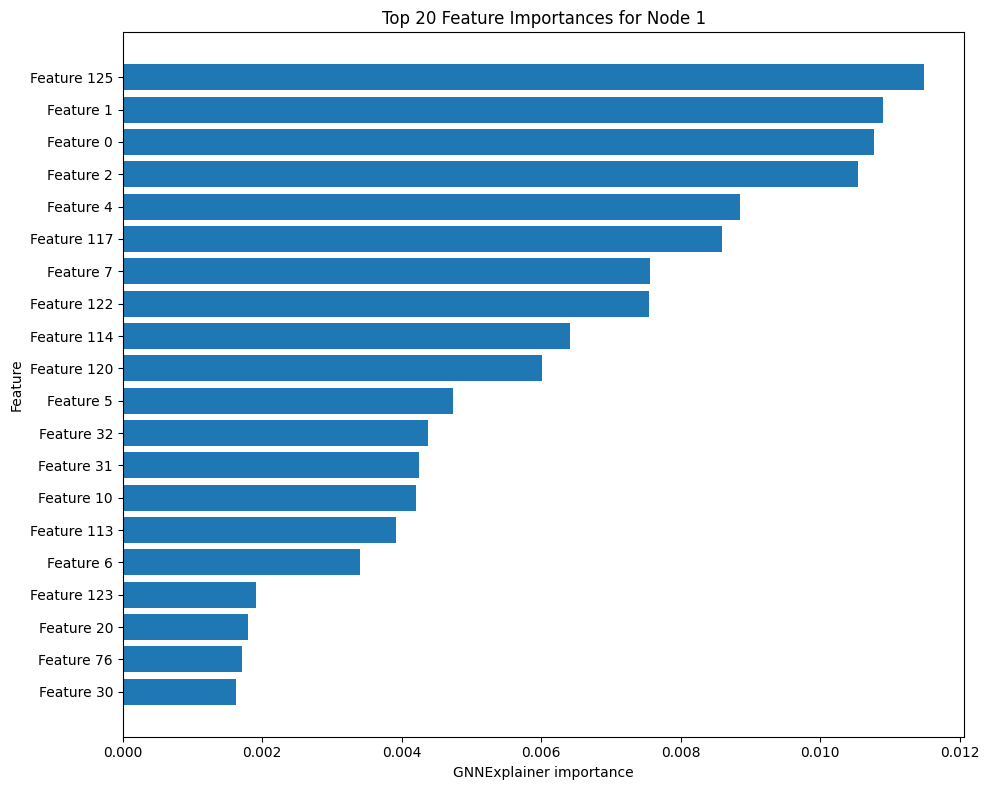

In [ ]:
# Plot top 20 feature importance values

top_indices_np = top_indices.numpy()[::-1]
top_values_np = top_values.numpy()[::-1]

plt.figure(figsize=(10, 8))

plt.barh(
    [f"Feature {i}" for i in top_indices_np],
    top_values_np
)

plt.xlabel("GNNExplainer importance")
plt.ylabel("Feature")
plt.title(
    f"Top 20 Feature Importances for Node {node_idx}"
)

plt.tight_layout()
plt.show()

In [ ]:
# Extract edge importance

edge_importance = explanation.edge_mask.detach().cpu()

top_edge_k = 20

top_edge_values, top_edge_indices = torch.topk(
    edge_importance,
    k=top_edge_k
)

print(f"Top {top_edge_k} important edges for node {node_idx}")
print()

for rank, (edge_idx, importance) in enumerate(
    zip(top_edge_indices, top_edge_values),
    start=1
):
    edge_idx = edge_idx.item()

    source = data.edge_index[0, edge_idx].item()
    target = data.edge_index[1, edge_idx].item()

    print(
        f"{rank:2d}. Edge {edge_idx:4d}: "
        f"{source} -> {target} "
        f"| Importance: {importance.item():.6f}"
    )

Top 20 important edges for node 1

 1. Edge 5921: 576 -> 1 | Importance: 0.926746
 2. Edge 2506: 250 -> 1 | Importance: 0.862616
 3. Edge 3043: 302 -> 1 | Importance: 0.829161
 4. Edge 3142: 312 -> 1 | Importance: 0.819146
 5. Edge   61: 6 -> 1 | Importance: 0.815351
 6. Edge  868: 86 -> 1 | Importance: 0.809602
 7. Edge    0: 0 -> 1 | Importance: 0.805185
 8. Edge 4246: 420 -> 1 | Importance: 0.114317
 9. Edge 6607: 637 -> 1 | Importance: 0.108901
10. Edge 5482: 534 -> 250 | Importance: 0.106667
11. Edge 4258: 420 -> 916 | Importance: 0.105293
12. Edge 9088: 864 -> 420 | Importance: 0.104775
13. Edge 3300: 329 -> 6 | Importance: 0.104389
14. Edge 1666: 165 -> 86 | Importance: 0.103792
15. Edge 6609: 637 -> 420 | Importance: 0.103767
16. Edge 9642: 914 -> 576 | Importance: 0.103416
17. Edge 5020: 491 -> 916 | Importance: 0.103361
18. Edge 10031: 951 -> 420 | Importance: 0.103258
19. Edge 4749: 467 -> 637 | Importance: 0.103151
20. Edge 7795: 748 -> 637 | Importance: 0.103080


In [ ]:
# Identify neighbors connected to the selected student

source_nodes = data.edge_index[0]
target_nodes = data.edge_index[1]

neighbor_edges = []

for edge_idx in range(data.edge_index.shape[1]):
    source = source_nodes[edge_idx].item()
    target = target_nodes[edge_idx].item()

    if source == node_idx or target == node_idx:
        neighbor_edges.append(edge_idx)

print("Number of edges involving selected node:", len(neighbor_edges))

# Sort those edges by explanation importance
neighbor_edges_sorted = sorted(
    neighbor_edges,
    key=lambda i: edge_importance[i].item(),
    reverse=True
)

print("\nMost important neighbors:")

for rank, edge_idx in enumerate(
    neighbor_edges_sorted[:20],
    start=1
):
    source = source_nodes[edge_idx].item()
    target = target_nodes[edge_idx].item()

    neighbor = target if source == node_idx else source

    print(
        f"{rank:2d}. Neighbor node: {neighbor:4d} "
        f"| Edge importance: {edge_importance[edge_idx].item():.6f}"
    )

Number of edges involving selected node: 20

Most important neighbors:
 1. Neighbor node:  576 | Edge importance: 0.926746
 2. Neighbor node:  250 | Edge importance: 0.862616
 3. Neighbor node:  302 | Edge importance: 0.829161
 4. Neighbor node:  312 | Edge importance: 0.819146
 5. Neighbor node:    6 | Edge importance: 0.815351
 6. Neighbor node:   86 | Edge importance: 0.809602
 7. Neighbor node:    0 | Edge importance: 0.805185
 8. Neighbor node:  420 | Edge importance: 0.114317
 9. Neighbor node:  637 | Edge importance: 0.108901
10. Neighbor node:  916 | Edge importance: 0.100526
11. Neighbor node:  576 | Edge importance: 0.093651
12. Neighbor node:   86 | Edge importance: 0.093219
13. Neighbor node:    0 | Edge importance: 0.092221
14. Neighbor node:  420 | Edge importance: 0.091525
15. Neighbor node:  916 | Edge importance: 0.090401
16. Neighbor node:  312 | Edge importance: 0.090269
17. Neighbor node:  637 | Edge importance: 0.089540
18. Neighbor node:    6 | Edge importance: 0.

In [ ]:
# Verify the selected student's prediction

model_gat.eval()

with torch.no_grad():
    original_output = model_gat(
        data.x,
        data.edge_index
    )[node_idx]

original_prediction = original_output.argmax().item()
actual_class = data.y[node_idx].item()

print("Selected node:", node_idx)
print("Actual class:", actual_class)
print("Model prediction:", original_prediction)

if actual_class == original_prediction:
    print("Prediction is CORRECT.")
else:
    print("Prediction is INCORRECT.")

Selected node: 1
Actual class: 2
Model prediction: 2
Prediction is CORRECT.


In [ ]:
# Save feature importance results

results_dir = "/content/drive/MyDrive/GNNExplainer_Results"

import os
os.makedirs(results_dir, exist_ok=True)

feature_results = pd.DataFrame({
    "feature_index": np.arange(len(feature_importance)),
    "importance": feature_importance.numpy()
})

feature_results = feature_results.sort_values(
    "importance",
    ascending=False
)

feature_csv_path = os.path.join(
    results_dir,
    f"node_{node_idx}_feature_importance.csv"
)

feature_results.to_csv(
    feature_csv_path,
    index=False
)

print("Feature importance saved to:")
print(feature_csv_path)

Feature importance saved to:
/content/drive/MyDrive/GNNExplainer_Results/node_1_feature_importance.csv


In [ ]:
# Save edge importance results

edge_rows = []

for edge_idx in range(data.edge_index.shape[1]):
    source = data.edge_index[0, edge_idx].item()
    target = data.edge_index[1, edge_idx].item()

    edge_rows.append({
        "edge_index": edge_idx,
        "source_node": source,
        "target_node": target,
        "importance": edge_importance[edge_idx].item()
    })

edge_results = pd.DataFrame(edge_rows)

edge_results = edge_results.sort_values(
    "importance",
    ascending=False
)

edge_csv_path = os.path.join(
    results_dir,
    f"node_{node_idx}_edge_importance.csv"
)

edge_results.to_csv(
    edge_csv_path,
    index=False
)

print("Edge importance saved to:")
print(edge_csv_path)

Edge importance saved to:
/content/drive/MyDrive/GNNExplainer_Results/node_1_edge_importance.csv


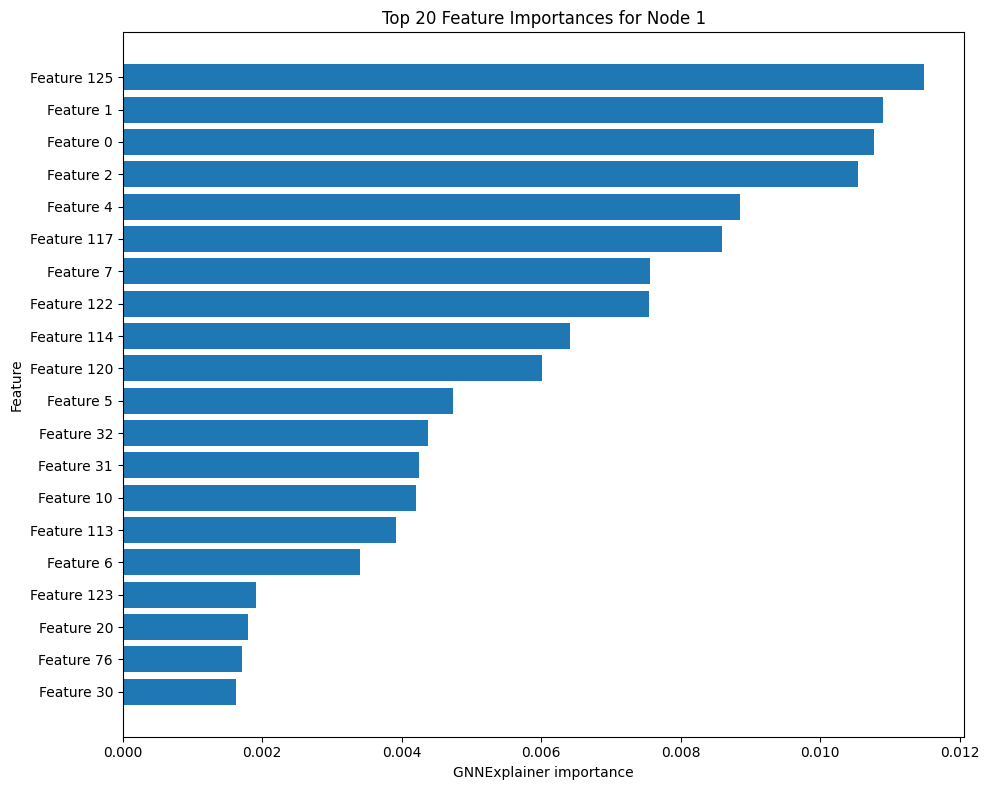

Plot saved to:
/content/drive/MyDrive/GNNExplainer_Results/node_1_top20_features.png


In [ ]:
# Save feature importance plot

plot_path = os.path.join(
    results_dir,
    f"node_{node_idx}_top20_features.png"
)

plt.figure(figsize=(10, 8))

plt.barh(
    [f"Feature {i}" for i in top_indices_np],
    top_values_np
)

plt.xlabel("GNNExplainer importance")
plt.ylabel("Feature")
plt.title(
    f"Top 20 Feature Importances for Node {node_idx}"
)

plt.tight_layout()
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to:")
print(plot_path)

In [ ]:
# Inspect all attributes stored in the graph

print(data)
print("\nGraph attributes:")
print(data.keys())

Data(x=[1000, 126], edge_index=[2, 10566], y=[1000], edge_weight=[10566], train_mask=[1000], val_mask=[1000], test_mask=[1000])

Graph attributes:
['x', 'test_mask', 'y', 'train_mask', 'val_mask', 'edge_weight', 'edge_index']


In [ ]:
# Check whether feature-name information is already available
# in the current Colab session.

possible_names = [
    "feature_names",
    "feature_cols",
    "feature_columns",
    "selected_features",
    "X_columns",
    "columns",
    "encoded_columns"
]

for name in possible_names:
    if name in globals():
        value = globals()[name]
        try:
            print(f"{name}: {len(value)} items")
            print(list(value)[:10])
        except:
            print(f"{name}: found, but could not inspect as a list")

In [ ]:
# Create a ranked feature-importance table

feature_importance_df = pd.DataFrame({
    "feature_index": np.arange(len(feature_importance)),
    "importance": feature_importance.numpy()
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["rank"] = np.arange(
    1, len(feature_importance_df) + 1
)

print(feature_importance_df.head(20))

    feature_index  importance  rank
0             125    0.011491     1
1               1    0.010896     2
2               0    0.010769     3
3               2    0.010537     4
4               4    0.008850     5
5             117    0.008587     6
6               7    0.007559     7
7             122    0.007544     8
8             114    0.006412     9
9             120    0.006006    10
10              5    0.004728    11
11             32    0.004382    12
12             31    0.004248    13
13             10    0.004201    14
14            113    0.003912    15
15              6    0.003399    16
16            123    0.001905    17
17             20    0.001798    18
18             76    0.001702    19
19             30    0.001626    20


In [ ]:
# Normalize feature importance to a 0–1 scale

max_importance = feature_importance_df["importance"].max()

feature_importance_df["normalized_importance"] = (
    feature_importance_df["importance"] / max_importance
)

print(feature_importance_df.head(20))

    feature_index  importance  rank  normalized_importance
0             125    0.011491     1               1.000000
1               1    0.010896     2               0.948212
2               0    0.010769     3               0.937120
3               2    0.010537     4               0.916927
4               4    0.008850     5               0.770185
5             117    0.008587     6               0.747257
6               7    0.007559     7               0.657794
7             122    0.007544     8               0.656498
8             114    0.006412     9               0.558038
9             120    0.006006    10               0.522654
10              5    0.004728    11               0.411447
11             32    0.004382    12               0.381358
12             31    0.004248    13               0.369713
13             10    0.004201    14               0.365602
14            113    0.003912    15               0.340408
15              6    0.003399    16               0.2957

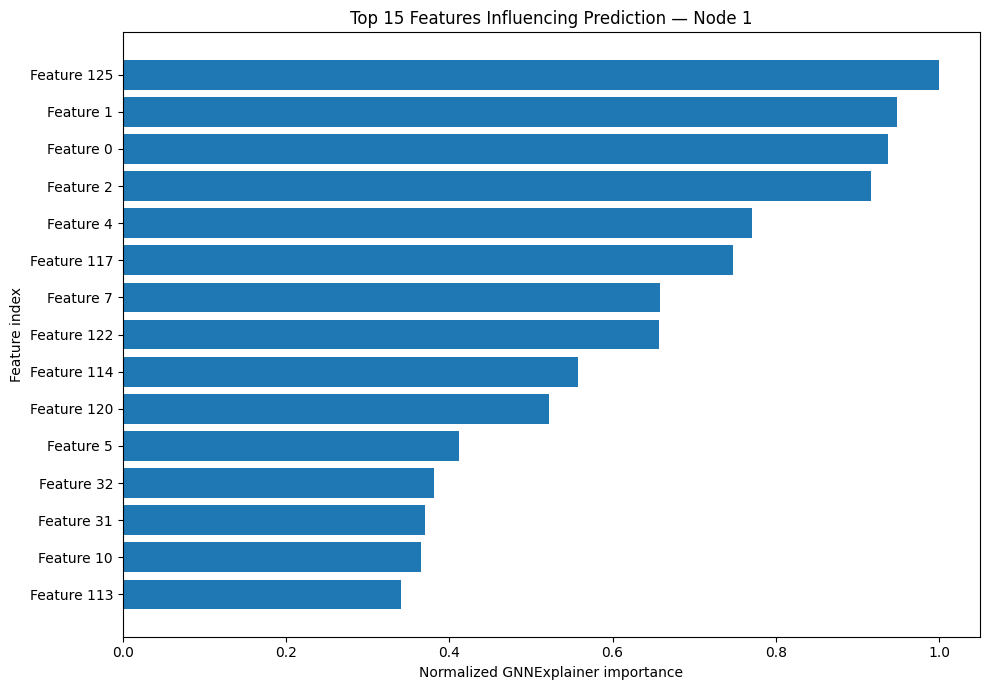

In [ ]:
# Plot top 15 feature importances

top15 = feature_importance_df.head(15).copy()

plt.figure(figsize=(10, 7))

plt.barh(
    [f"Feature {i}" for i in top15["feature_index"][::-1]],
    top15["normalized_importance"][::-1]
)

plt.xlabel("Normalized GNNExplainer importance")
plt.ylabel("Feature index")
plt.title(
    f"Top 15 Features Influencing Prediction — Node {node_idx}"
)

plt.tight_layout()
plt.show()

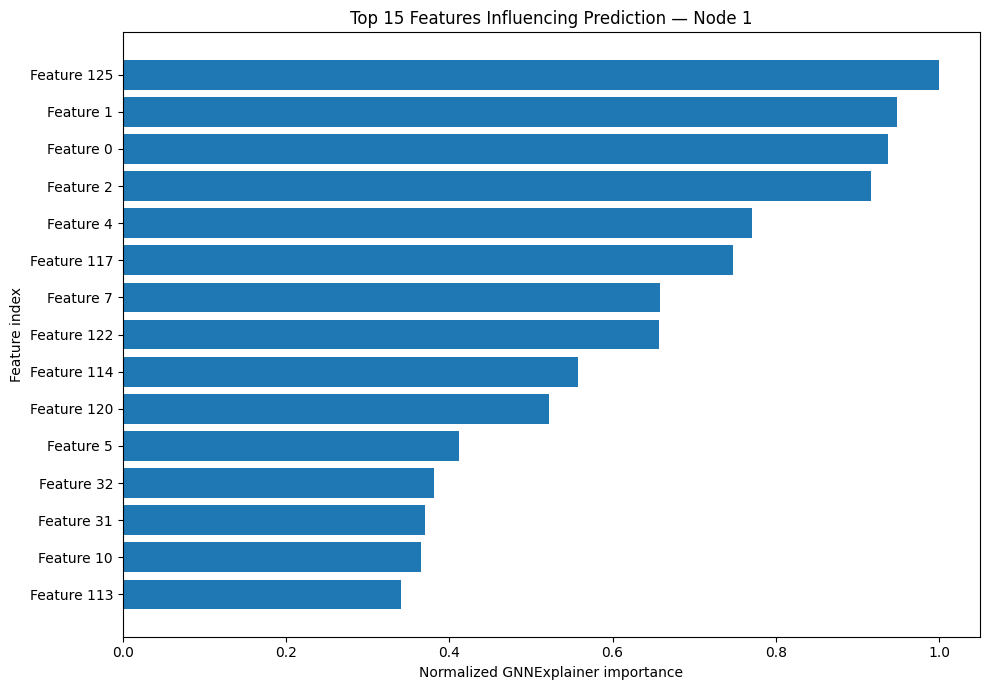

Saved: /content/drive/MyDrive/GNNExplainer_Results/node_1_top15_features.png


In [ ]:
# Save the top-15 feature importance figure

top15_plot_path = os.path.join(
    results_dir,
    f"node_{node_idx}_top15_features.png"
)

plt.figure(figsize=(10, 7))

plt.barh(
    [f"Feature {i}" for i in top15["feature_index"][::-1]],
    top15["normalized_importance"][::-1]
)

plt.xlabel("Normalized GNNExplainer importance")
plt.ylabel("Feature index")
plt.title(
    f"Top 15 Features Influencing Prediction — Node {node_idx}"
)

plt.tight_layout()

plt.savefig(
    top15_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", top15_plot_path)

In [ ]:
# Create ranked edge-importance table

edge_importance_df = pd.DataFrame({
    "edge_index": np.arange(len(edge_importance)),
    "importance": edge_importance.numpy(),
    "source_node": data.edge_index[0].detach().cpu().numpy(),
    "target_node": data.edge_index[1].detach().cpu().numpy()
})

edge_importance_df = edge_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

edge_importance_df["rank"] = np.arange(
    1,
    len(edge_importance_df) + 1
)

print(edge_importance_df.head(20))

    edge_index  importance  source_node  target_node  rank
0         5921    0.926746          576            1     1
1         2506    0.862616          250            1     2
2         3043    0.829161          302            1     3
3         3142    0.819146          312            1     4
4           61    0.815351            6            1     5
5          868    0.809602           86            1     6
6            0    0.805185            0            1     7
7         4246    0.114317          420            1     8
8         6607    0.108901          637            1     9
9         5482    0.106667          534          250    10
10        4258    0.105293          420          916    11
11        9088    0.104775          864          420    12
12        3300    0.104389          329            6    13
13        1666    0.103792          165           86    14
14        6609    0.103767          637          420    15
15        9642    0.103416          914          576    

In [ ]:
# Important edges directly connected to the selected student

selected_edges = edge_importance_df[
    (edge_importance_df["source_node"] == node_idx) |
    (edge_importance_df["target_node"] == node_idx)
].copy()

print(
    f"Edges directly connected to node {node_idx}:",
    len(selected_edges)
)

print("\nTop connected edges:")
print(selected_edges.head(20))

Edges directly connected to node 1: 20

Top connected edges:
     edge_index  importance  source_node  target_node  rank
0          5921    0.926746          576            1     1
1          2506    0.862616          250            1     2
2          3043    0.829161          302            1     3
3          3142    0.819146          312            1     4
4            61    0.815351            6            1     5
5           868    0.809602           86            1     6
6             0    0.805185            0            1     7
7          4246    0.114317          420            1     8
8          6607    0.108901          637            1     9
56         9659    0.100526          916            1    57
96           18    0.093651            1          576    97
99           13    0.093219            1           86   100
102          11    0.092221            1            0   103
105          17    0.091525            1          420   106
111          20    0.090401            

In [ ]:
# Get the most important neighboring nodes

top_neighbors = []

for _, row in selected_edges.head(20).iterrows():

    source = int(row["source_node"])
    target = int(row["target_node"])

    if source == node_idx:
        neighbor = target
    else:
        neighbor = source

    top_neighbors.append({
        "neighbor_node": neighbor,
        "edge_importance": row["importance"]
    })

top_neighbors_df = pd.DataFrame(top_neighbors)

print(top_neighbors_df)

    neighbor_node  edge_importance
0             576         0.926746
1             250         0.862616
2             302         0.829161
3             312         0.819146
4               6         0.815351
5              86         0.809602
6               0         0.805185
7             420         0.114317
8             637         0.108901
9             916         0.100526
10            576         0.093651
11             86         0.093219
12              0         0.092221
13            420         0.091525
14            916         0.090401
15            312         0.090269
16            637         0.089540
17              6         0.088241
18            302         0.086524
19            250         0.085555


In [ ]:
# Translate numerical class to risk category

class_names = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

actual_class = int(data.y[node_idx].item())
predicted_class = int(predictions[node_idx].item())

print("Node:", node_idx)
print("Actual class:", actual_class, "-", class_names[actual_class])
print("Predicted class:", predicted_class, "-", class_names[predicted_class])

Node: 1
Actual class: 2 - High Risk
Predicted class: 2 - High Risk


In [ ]:
# Create a summary of the explanation

explanation_summary = {
    "node_index": node_idx,
    "actual_class": actual_class,
    "actual_class_name": class_names[actual_class],
    "predicted_class": predicted_class,
    "predicted_class_name": class_names[predicted_class],
    "prediction_correct": actual_class == predicted_class,
    "number_of_features": data.x.shape[1],
    "number_of_graph_edges": data.edge_index.shape[1],
    "top_feature_index": int(feature_importance_df.iloc[0]["feature_index"]),
    "top_feature_importance": float(feature_importance_df.iloc[0]["importance"]),
    "top_neighbor": int(top_neighbors_df.iloc[0]["neighbor_node"])
        if len(top_neighbors_df) > 0 else None
}

for key, value in explanation_summary.items():
    print(f"{key}: {value}")

node_index: 1
actual_class: 2
actual_class_name: High Risk
predicted_class: 2
predicted_class_name: High Risk
prediction_correct: True
number_of_features: 126
number_of_graph_edges: 10566
top_feature_index: 125
top_feature_importance: 0.011491156183183193
top_neighbor: 576


In [ ]:
# Save explanation summary

summary_df = pd.DataFrame([explanation_summary])

summary_path = os.path.join(
    results_dir,
    f"node_{node_idx}_explanation_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("Summary saved to:")
print(summary_path)

Summary saved to:
/content/drive/MyDrive/GNNExplainer_Results/node_1_explanation_summary.csv


In [ ]:
# Find correctly classified test students by class

correct_test_mask = (
    data.test_mask &
    (predictions == data.y)
)

correct_nodes = torch.where(correct_test_mask)[0]

for class_id in [0, 1, 2]:

    class_nodes = correct_nodes[
        data.y[correct_nodes] == class_id
    ]

    print(
        f"{class_names[class_id]} (Class {class_id}): "
        f"{len(class_nodes)} correctly classified students"
    )

Low Risk (Class 0): 47 correctly classified students
Medium Risk (Class 1): 42 correctly classified students
High Risk (Class 2): 36 correctly classified students


In [ ]:
# Select up to 3 correctly classified students from each class

nodes_to_explain = []

for class_id in [0, 1, 2]:

    class_nodes = correct_nodes[
        data.y[correct_nodes] == class_id
    ]

    selected = class_nodes[:3].tolist()

    nodes_to_explain.extend(selected)

    print(
        f"\n{class_names[class_id]}:"
    )

    for node in selected:
        print(
            "Node:",
            node,
            "| Class:",
            data.y[node].item()
        )

print("\nTotal students selected:", len(nodes_to_explain))


Low Risk:
Node: 298 | Class: 0
Node: 322 | Class: 0
Node: 325 | Class: 0

Medium Risk:
Node: 4 | Class: 1
Node: 14 | Class: 1
Node: 96 | Class: 1

High Risk:
Node: 1 | Class: 2
Node: 6 | Class: 2
Node: 16 | Class: 2

Total students selected: 9


In [ ]:
# Generate GNNExplainer explanations for all selected students

all_explanations = {}

for i, node in enumerate(nodes_to_explain, start=1):

    print(
        f"\nExplaining student {i}/{len(nodes_to_explain)} "
        f"(node {node})..."
    )

    explanation_i = explainer(
        x=data.x,
        edge_index=data.edge_index,
        index=node
    )

    all_explanations[node] = explanation_i

    print("Completed.")

print(
    "\nAll explanations generated:",
    len(all_explanations)
)


Explaining student 1/9 (node 298)...
Completed.

Explaining student 2/9 (node 322)...
Completed.

Explaining student 3/9 (node 325)...
Completed.

Explaining student 4/9 (node 4)...
Completed.

Explaining student 5/9 (node 14)...
Completed.

Explaining student 6/9 (node 96)...
Completed.

Explaining student 7/9 (node 1)...
Completed.

Explaining student 8/9 (node 6)...
Completed.

Explaining student 9/9 (node 16)...
Completed.

All explanations generated: 9


In [ ]:
# Aggregate feature importance across all explained students

all_feature_masks = []

for node, explanation_i in all_explanations.items():

    mask = explanation_i.node_mask.abs()

    if mask.dim() > 1:
        mask = mask.mean(dim=0)

    all_feature_masks.append(
        mask.detach().cpu()
    )

all_feature_masks = torch.stack(all_feature_masks)

global_feature_importance = all_feature_masks.mean(dim=0)

print(
    "Global feature importance shape:",
    global_feature_importance.shape
)

Global feature importance shape: torch.Size([126])


In [ ]:
global_feature_df = pd.DataFrame({
    "feature_index": np.arange(len(global_feature_importance)),
    "mean_importance": global_feature_importance.numpy()
})

global_feature_df = global_feature_df.sort_values(
    "mean_importance",
    ascending=False
).reset_index(drop=True)

global_feature_df["rank"] = np.arange(
    1,
    len(global_feature_df) + 1
)

print(global_feature_df.head(20))

    feature_index  mean_importance  rank
0               0         0.008229     1
1               1         0.008172     2
2               2         0.008074     3
3               7         0.006371     4
4             120         0.006231     5
5             125         0.005959     6
6             122         0.005137     7
7             114         0.003886     8
8             117         0.003876     9
9               4         0.003816    10
10             32         0.003657    11
11             31         0.003375    12
12            113         0.003328    13
13              5         0.003221    14
14              3         0.003117    15
15            123         0.002991    16
16            124         0.002624    17
17              6         0.002206    18
18             25         0.002170    19
19             76         0.001711    20


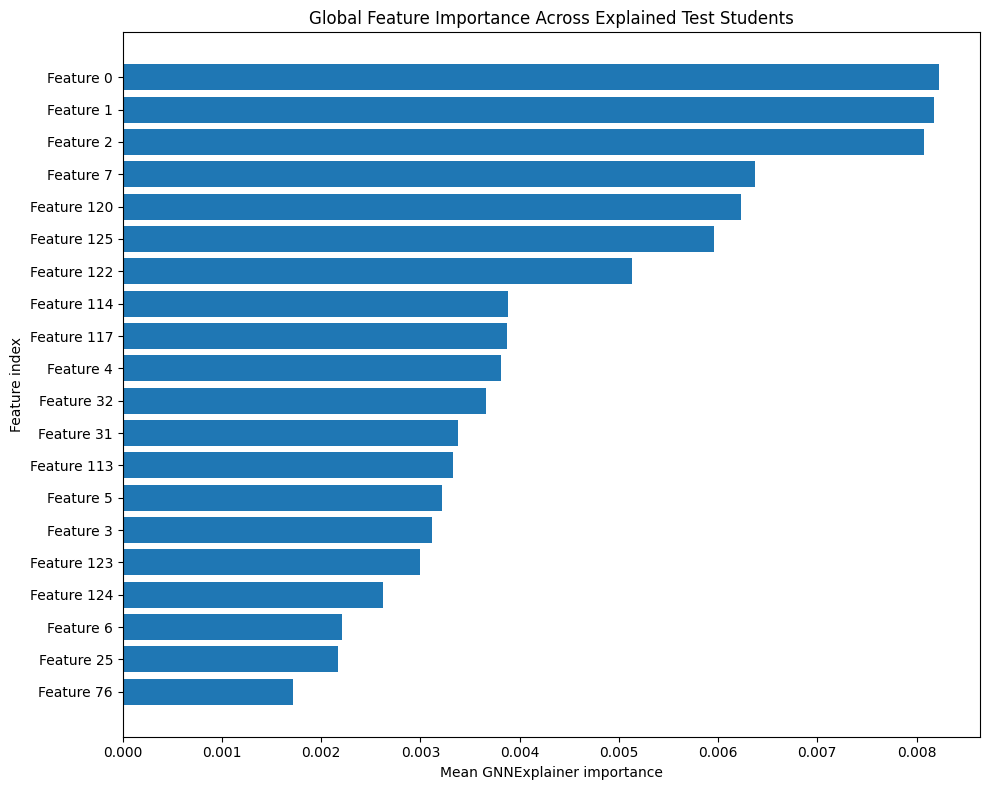

In [ ]:
# Plot global GNNExplainer feature importance

top_global = global_feature_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    [f"Feature {i}" for i in top_global["feature_index"][::-1]],
    top_global["mean_importance"][::-1]
)

plt.xlabel("Mean GNNExplainer importance")
plt.ylabel("Feature index")
plt.title(
    "Global Feature Importance Across Explained Test Students"
)

plt.tight_layout()
plt.show()

In [ ]:
# Save global feature importance

global_feature_path = os.path.join(
    results_dir,
    "global_feature_importance.csv"
)

global_feature_df.to_csv(
    global_feature_path,
    index=False
)

print("Global feature importance saved to:")
print(global_feature_path)

Global feature importance saved to:
/content/drive/MyDrive/GNNExplainer_Results/global_feature_importance.csv


In [ ]:
# Calculate feature importance separately for each risk class

class_feature_results = {}

for class_id in [0, 1, 2]:

    class_nodes = [
        node for node in nodes_to_explain
        if int(data.y[node].item()) == class_id
    ]

    class_masks = []

    for node in class_nodes:

        mask = all_explanations[node].node_mask.abs()

        if mask.dim() > 1:
            mask = mask.mean(dim=0)

        class_masks.append(mask.detach().cpu())

    if len(class_masks) > 0:

        class_mean = torch.stack(class_masks).mean(dim=0)

        class_feature_results[class_id] = class_mean

        print(
            class_names[class_id],
            "->",
            class_mean.shape
        )

Low Risk -> torch.Size([126])
Medium Risk -> torch.Size([126])
High Risk -> torch.Size([126])


In [ ]:
# Display the top 10 features for each risk class

for class_id, importance_values in class_feature_results.items():

    values, indices = torch.topk(
        importance_values,
        k=10
    )

    print(
        f"\n===== {class_names[class_id]} ====="
    )

    for rank, (idx, value) in enumerate(
        zip(indices, values),
        start=1
    ):
        print(
            f"{rank:2d}. Feature {idx.item():3d}"
            f" | Importance: {value.item():.6f}"
        )


===== Low Risk =====
 1. Feature   1 | Importance: 0.008940
 2. Feature   2 | Importance: 0.008886
 3. Feature   0 | Importance: 0.008875
 4. Feature 120 | Importance: 0.008364
 5. Feature   7 | Importance: 0.007356
 6. Feature   3 | Importance: 0.005723
 7. Feature 125 | Importance: 0.005604
 8. Feature 122 | Importance: 0.005494
 9. Feature  31 | Importance: 0.004819
10. Feature 113 | Importance: 0.004378

===== Medium Risk =====
 1. Feature   0 | Importance: 0.007768
 2. Feature   1 | Importance: 0.007684
 3. Feature   2 | Importance: 0.007453
 4. Feature 120 | Importance: 0.006887
 5. Feature   7 | Importance: 0.006639
 6. Feature  32 | Importance: 0.005383
 7. Feature 122 | Importance: 0.005347
 8. Feature 125 | Importance: 0.005271
 9. Feature   5 | Importance: 0.004616
10. Feature  20 | Importance: 0.003465

===== High Risk =====
 1. Feature 117 | Importance: 0.009646
 2. Feature   4 | Importance: 0.009333
 3. Feature   0 | Importance: 0.008042
 4. Feature   1 | Importance: 0.0

In [ ]:
# Save class-specific feature importance

class_rows = []

for class_id, importance_values in class_feature_results.items():

    for feature_idx, importance in enumerate(importance_values):

        class_rows.append({
            "class": class_id,
            "class_name": class_names[class_id],
            "feature_index": feature_idx,
            "mean_importance": importance.item()
        })

class_feature_df = pd.DataFrame(class_rows)

class_feature_path = os.path.join(
    results_dir,
    "class_specific_feature_importance.csv"
)

class_feature_df.to_csv(
    class_feature_path,
    index=False
)

print("Class-specific results saved to:")
print(class_feature_path)

Class-specific results saved to:
/content/drive/MyDrive/GNNExplainer_Results/class_specific_feature_importance.csv


In [ ]:
# Generate GNNExplainer explanations for all selected students

all_explanations = {}

for i, node in enumerate(nodes_to_explain, start=1):

    print(
        f"\nExplaining student {i}/{len(nodes_to_explain)} "
        f"(node {node})..."
    )

    explanation_i = explainer(
        x=data.x,
        edge_index=data.edge_index,
        index=node
    )

    all_explanations[node] = explanation_i

    print("Completed.")

print(
    "\nAll explanations generated:",
    len(all_explanations)
)


Explaining student 1/9 (node 298)...
Completed.

Explaining student 2/9 (node 322)...
Completed.

Explaining student 3/9 (node 325)...
Completed.

Explaining student 4/9 (node 4)...
Completed.

Explaining student 5/9 (node 14)...
Completed.

Explaining student 6/9 (node 96)...
Completed.

Explaining student 7/9 (node 1)...
Completed.

Explaining student 8/9 (node 6)...
Completed.

Explaining student 9/9 (node 16)...
Completed.

All explanations generated: 9


In [ ]:
# Cell 46: Aggregate feature importance across all 9 explained students

all_feature_masks = []

for node, explanation_i in all_explanations.items():

    mask = explanation_i.node_mask.abs()

    # If mask has multiple dimensions, average across them
    if mask.dim() > 1:
        mask = mask.mean(dim=0)

    all_feature_masks.append(mask.detach().cpu())

# Stack all students' feature importance
all_feature_masks = torch.stack(all_feature_masks)

# Average importance across the 9 students
global_feature_importance = all_feature_masks.mean(dim=0)

print("Feature importance matrix shape:", all_feature_masks.shape)
print("Global feature importance shape:", global_feature_importance.shape)
print("Number of explained students:", len(all_explanations))

Feature importance matrix shape: torch.Size([9, 126])
Global feature importance shape: torch.Size([126])
Number of explained students: 9


In [ ]:
# Cell 47: Rank global feature importance

feature_indices = list(range(global_feature_importance.shape[0]))

global_feature_df = pd.DataFrame({
    "Feature_Index": feature_indices,
    "Feature": [f"Feature_{i}" for i in feature_indices],
    "Importance": global_feature_importance.numpy()
})

# Sort from most important to least important
global_feature_df = global_feature_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Add rank
global_feature_df.insert(
    0,
    "Rank",
    range(1, len(global_feature_df) + 1)
)

print("Top 20 globally important features:")
display(global_feature_df.head(20))

Top 20 globally important features:


,Rank,Feature_Index,Feature,Importance
0,1,1,Feature_1,0.008182
1,2,0,Feature_0,0.008168
2,3,2,Feature_2,0.008045
3,4,7,Feature_7,0.006346
4,5,120,Feature_120,0.006280
5,6,125,Feature_125,0.005927
6,7,122,Feature_122,0.005157
7,8,114,Feature_114,0.003883
8,9,117,Feature_117,0.003879
9,10,4,Feature_4,0.003800


In [ ]:
# Cell 48: Normalize global feature importance

max_importance = global_feature_df["Importance"].max()

if max_importance > 0:
    global_feature_df["Normalized_Importance"] = (
        global_feature_df["Importance"] / max_importance
    )
else:
    global_feature_df["Normalized_Importance"] = 0

print("Normalized importance added successfully.")

display(global_feature_df.head(20))

Normalized importance added successfully.


,Rank,Feature_Index,Feature,Importance,Normalized_Importance
0,1,1,Feature_1,0.008182,1.000000
1,2,0,Feature_0,0.008168,0.998364
2,3,2,Feature_2,0.008045,0.983254
3,4,7,Feature_7,0.006346,0.775604
4,5,120,Feature_120,0.006280,0.767503
5,6,125,Feature_125,0.005927,0.724383
6,7,122,Feature_122,0.005157,0.630342
7,8,114,Feature_114,0.003883,0.474602
8,9,117,Feature_117,0.003879,0.474101
9,10,4,Feature_4,0.003800,0.464396


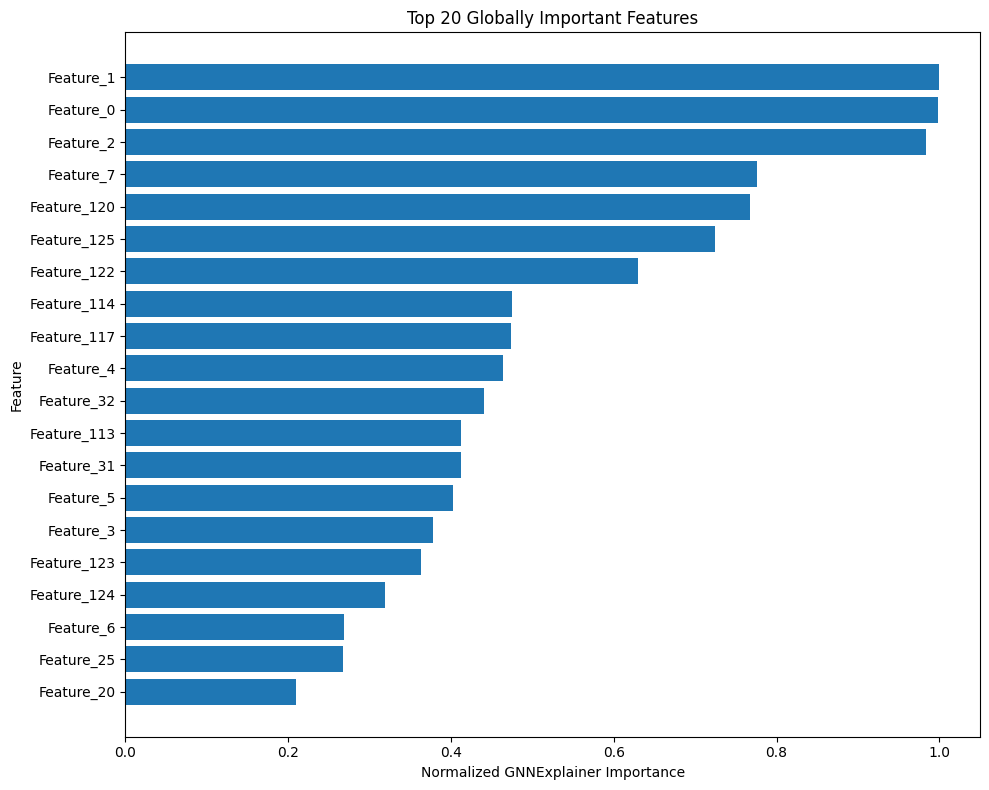

In [ ]:
# Cell 49: Plot top 20 globally important features

top20_global = global_feature_df.head(20).sort_values(
    by="Normalized_Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_global["Feature"],
    top20_global["Normalized_Importance"]
)

plt.xlabel("Normalized GNNExplainer Importance")
plt.ylabel("Feature")
plt.title("Top 20 Globally Important Features")
plt.tight_layout()

plt.show()

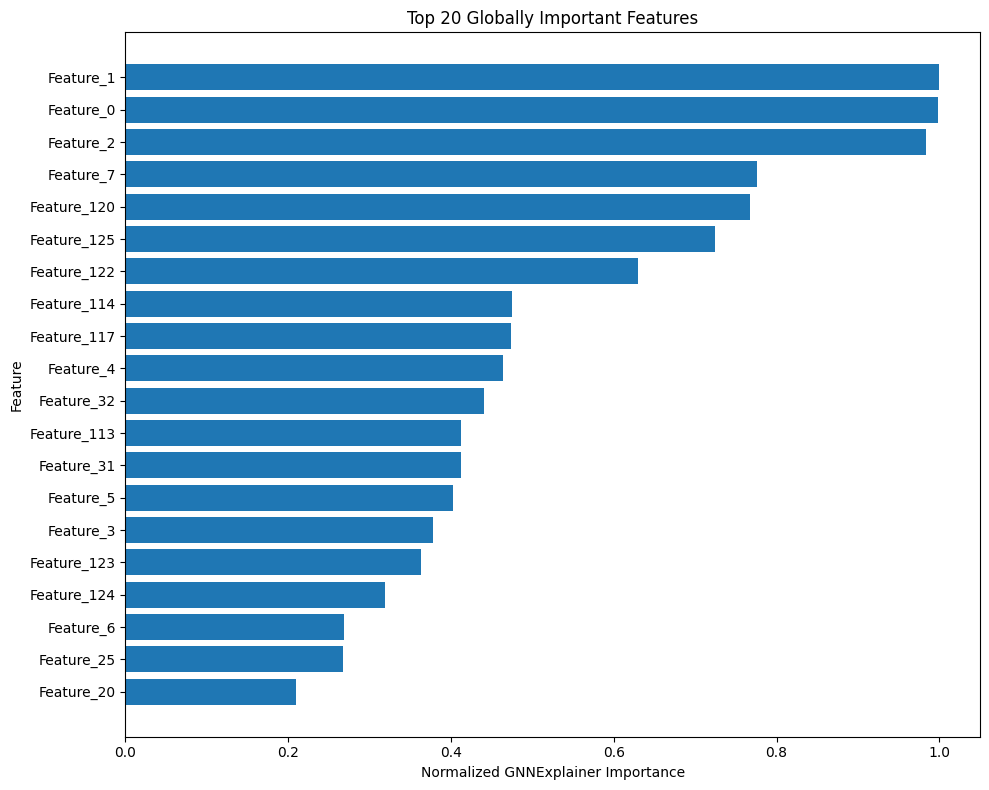

Plot saved to:
/content/drive/MyDrive/GNNExplainer_Global_Top20_Features.png


In [ ]:
# Cell 50: Save global feature importance plot

global_plot_path = "/content/drive/MyDrive/GNNExplainer_Global_Top20_Features.png"

plt.figure(figsize=(10, 8))

top20_global = global_feature_df.head(20).sort_values(
    by="Normalized_Importance",
    ascending=True
)

plt.barh(
    top20_global["Feature"],
    top20_global["Normalized_Importance"]
)

plt.xlabel("Normalized GNNExplainer Importance")
plt.ylabel("Feature")
plt.title("Top 20 Globally Important Features")
plt.tight_layout()

plt.savefig(global_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to:")
print(global_plot_path)

In [ ]:
# Cell 51: Save global feature importance CSV

global_csv_path = "/content/drive/MyDrive/GNNExplainer_Global_Feature_Importance.csv"

global_feature_df.to_csv(
    global_csv_path,
    index=False
)

print("Global feature importance saved successfully:")
print(global_csv_path)

Global feature importance saved successfully:
/content/drive/MyDrive/GNNExplainer_Global_Feature_Importance.csv


In [ ]:
# Cell 52: Class-specific feature importance

class_feature_importance = {}

for class_id in [0, 1, 2]:

    class_masks = []

    for node, explanation_i in all_explanations.items():

        # Get the student's true class
        student_class = int(data.y[node].item())

        if student_class != class_id:
            continue

        mask = explanation_i.node_mask.abs()

        if mask.dim() > 1:
            mask = mask.mean(dim=0)

        class_masks.append(mask.detach().cpu())

    if len(class_masks) > 0:

        class_masks = torch.stack(class_masks)

        class_importance = class_masks.mean(dim=0)

        class_feature_importance[class_id] = class_importance

        print(
            f"Class {class_id}: "
            f"{len(class_masks)} students explained"
        )
        print(
            "Feature vector shape:",
            class_importance.shape
        )

    else:
        print(f"No explanations found for class {class_id}.")

Class 0: 3 students explained
Feature vector shape: torch.Size([126])
Class 1: 3 students explained
Feature vector shape: torch.Size([126])
Class 2: 3 students explained
Feature vector shape: torch.Size([126])


In [ ]:
# Cell 53: Create ranked feature importance for each class

class_names = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

class_feature_dfs = {}

for class_id, importance in class_feature_importance.items():

    df = pd.DataFrame({
        "Feature_Index": range(len(importance)),
        "Feature": [
            f"Feature_{i}"
            for i in range(len(importance))
        ],
        "Importance": importance.numpy()
    })

    df = df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    df.insert(
        0,
        "Rank",
        range(1, len(df) + 1)
    )

    df["Risk_Class"] = class_names[class_id]

    class_feature_dfs[class_id] = df

    print(f"\n===== {class_names[class_id]} =====")
    display(df.head(10))


===== Low Risk =====


,Rank,Feature_Index,Feature,Importance,Risk_Class
0,1,1,Feature_1,0.008920,Low Risk
1,2,0,Feature_0,0.008825,Low Risk
2,3,2,Feature_2,0.008807,Low Risk
3,4,120,Feature_120,0.008431,Low Risk
4,5,7,Feature_7,0.007355,Low Risk
5,6,3,Feature_3,0.005704,Low Risk
6,7,125,Feature_125,0.005645,Low Risk
7,8,122,Feature_122,0.005549,Low Risk
8,9,31,Feature_31,0.004813,Low Risk
9,10,113,Feature_113,0.004381,Low Risk



===== Medium Risk =====


,Rank,Feature_Index,Feature,Importance,Risk_Class
0,1,1,Feature_1,0.007678,Medium Risk
1,2,0,Feature_0,0.007643,Medium Risk
2,3,2,Feature_2,0.007454,Medium Risk
3,4,120,Feature_120,0.006933,Medium Risk
4,5,7,Feature_7,0.006599,Medium Risk
5,6,122,Feature_122,0.005319,Medium Risk
6,7,125,Feature_125,0.005270,Medium Risk
7,8,32,Feature_32,0.005266,Medium Risk
8,9,5,Feature_5,0.004841,Medium Risk
9,10,20,Feature_20,0.003457,Medium Risk



===== High Risk =====


,Rank,Feature_Index,Feature,Importance,Risk_Class
0,1,117,Feature_117,0.009606,High Risk
1,2,4,Feature_4,0.009259,High Risk
2,3,0,Feature_0,0.008036,High Risk
3,4,1,Feature_1,0.007947,High Risk
4,5,2,Feature_2,0.007873,High Risk
5,6,125,Feature_125,0.006865,High Risk
6,7,114,Feature_114,0.005373,High Risk
7,8,7,Feature_7,0.005083,High Risk
8,9,122,Feature_122,0.004603,High Risk
9,10,120,Feature_120,0.003475,High Risk


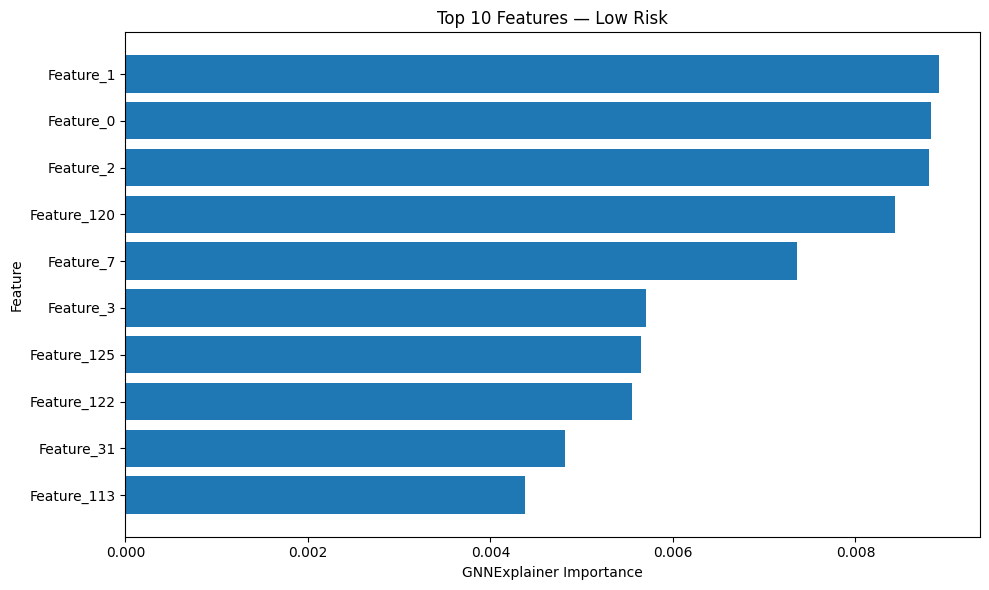

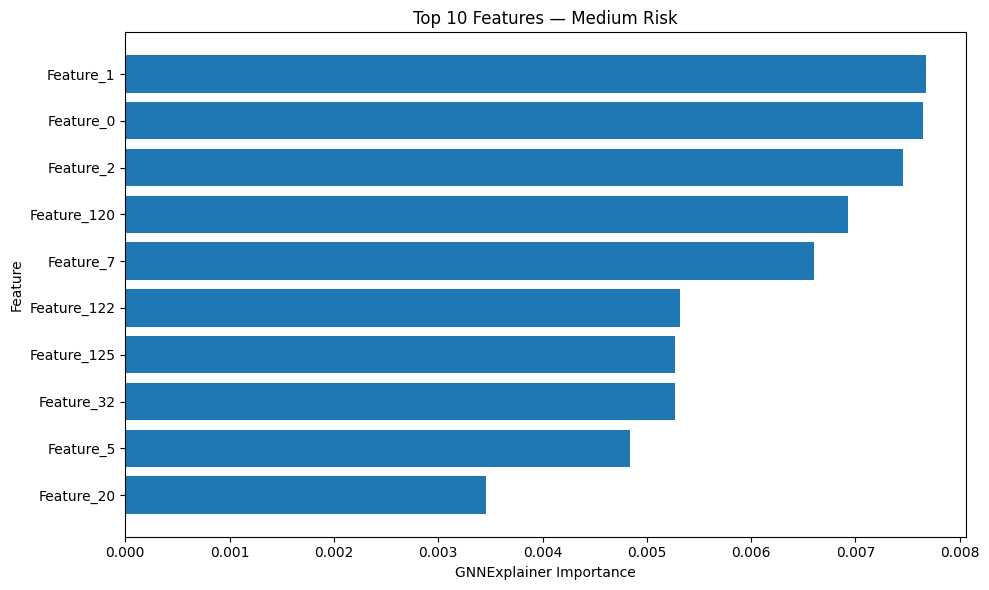

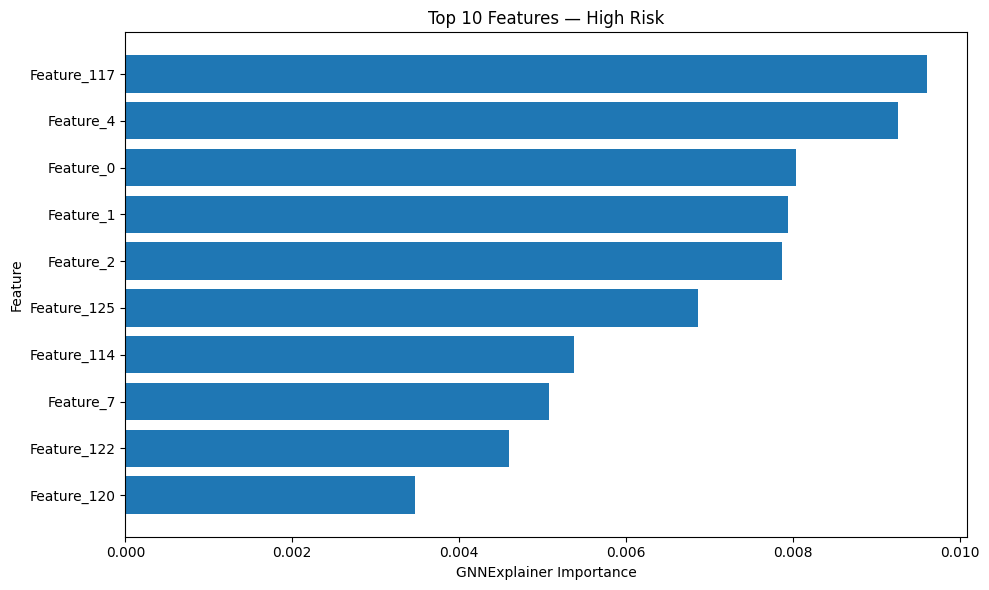

In [ ]:
# Cell 54: Plot class-specific feature importance

for class_id, df in class_feature_dfs.items():

    top10 = df.head(10).sort_values(
        by="Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top10["Feature"],
        top10["Importance"]
    )

    plt.xlabel("GNNExplainer Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top 10 Features — {class_names[class_id]}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 55: Save class-specific feature importance

class_results_path = "/content/drive/MyDrive/GNNExplainer_Class_Specific_Features.csv"

combined_class_df = pd.concat(
    class_feature_dfs.values(),
    ignore_index=True
)

combined_class_df.to_csv(
    class_results_path,
    index=False
)

print("Class-specific feature importance saved:")
print(class_results_path)

Class-specific feature importance saved:
/content/drive/MyDrive/GNNExplainer_Class_Specific_Features.csv


In [ ]:
# Cell 56: Display top 15 global features

print("==========================================")
print("TOP 15 GLOBALLY IMPORTANT FEATURES")
print("==========================================")

display(
    global_feature_df[
        [
            "Rank",
            "Feature_Index",
            "Feature",
            "Importance",
            "Normalized_Importance"
        ]
    ].head(15)
)

TOP 15 GLOBALLY IMPORTANT FEATURES


,Rank,Feature_Index,Feature,Importance,Normalized_Importance
0,1,1,Feature_1,0.008182,1.000000
1,2,0,Feature_0,0.008168,0.998364
2,3,2,Feature_2,0.008045,0.983254
3,4,7,Feature_7,0.006346,0.775604
4,5,120,Feature_120,0.006280,0.767503
5,6,125,Feature_125,0.005927,0.724383
6,7,122,Feature_122,0.005157,0.630342
7,8,114,Feature_114,0.003883,0.474602
8,9,117,Feature_117,0.003879,0.474101
9,10,4,Feature_4,0.003800,0.464396


In [ ]:
# Cell 57: Compare top 10 features across risk classes

comparison_df = pd.DataFrame()

for class_id, df in class_feature_dfs.items():

    temp = df.head(10)[
        ["Feature", "Importance"]
    ].copy()

    temp["Risk_Class"] = class_names[class_id]

    comparison_df = pd.concat(
        [comparison_df, temp],
        ignore_index=True
    )

display(comparison_df)

,Feature,Importance,Risk_Class
0,Feature_1,0.008920,Low Risk
1,Feature_0,0.008825,Low Risk
2,Feature_2,0.008807,Low Risk
3,Feature_120,0.008431,Low Risk
4,Feature_7,0.007355,Low Risk
5,Feature_3,0.005704,Low Risk
6,Feature_125,0.005645,Low Risk
7,Feature_122,0.005549,Low Risk
8,Feature_31,0.004813,Low Risk
9,Feature_113,0.004381,Low Risk


In [ ]:
# Cell 58: Find features appearing in the top 10 of multiple classes

top_features_by_class = {}

for class_id, df in class_feature_dfs.items():

    top_features_by_class[class_id] = set(
        df.head(10)["Feature"]
    )

all_top_features = set().union(
    *top_features_by_class.values()
)

shared_features = []

for feature in all_top_features:

    classes_present = [
        class_names[class_id]
        for class_id, features in top_features_by_class.items()
        if feature in features
    ]

    if len(classes_present) >= 2:

        shared_features.append({
            "Feature": feature,
            "Number_of_Classes": len(classes_present),
            "Classes": ", ".join(classes_present)
        })

shared_features_df = pd.DataFrame(shared_features)

print("Features appearing in the top 10 for at least two classes:")

display(
    shared_features_df.sort_values(
        by="Number_of_Classes",
        ascending=False
    )
)

Features appearing in the top 10 for at least two classes:


,Feature,Number_of_Classes,Classes
0,Feature_120,3,"Low Risk, Medium Risk, High Risk"
1,Feature_125,3,"Low Risk, Medium Risk, High Risk"
2,Feature_122,3,"Low Risk, Medium Risk, High Risk"
3,Feature_7,3,"Low Risk, Medium Risk, High Risk"
4,Feature_2,3,"Low Risk, Medium Risk, High Risk"
5,Feature_0,3,"Low Risk, Medium Risk, High Risk"
6,Feature_1,3,"Low Risk, Medium Risk, High Risk"


In [ ]:
# Cell 59: Save all GNNExplainer results to Excel

excel_path = "/content/drive/MyDrive/GNNExplainer_Final_Results.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # 1. Global feature importance
    global_feature_df.to_excel(
        writer,
        sheet_name="Global_Features",
        index=False
    )

    # 2. Low-risk features
    if 0 in class_feature_dfs:
        class_feature_dfs[0].to_excel(
            writer,
            sheet_name="Low_Risk",
            index=False
        )

    # 3. Medium-risk features
    if 1 in class_feature_dfs:
        class_feature_dfs[1].to_excel(
            writer,
            sheet_name="Medium_Risk",
            index=False
        )

    # 4. High-risk features
    if 2 in class_feature_dfs:
        class_feature_dfs[2].to_excel(
            writer,
            sheet_name="High_Risk",
            index=False
        )

    # 5. Shared features, if available
    if "shared_features_df" in globals() and len(shared_features_df) > 0:
        shared_features_df.to_excel(
            writer,
            sheet_name="Shared_Features",
            index=False
        )

    # 6. Explained students
    explained_students = []

    for node in all_explanations.keys():

        true_class = int(data.y[node].item())

        # Get model prediction
        model_gat.eval()

        with torch.no_grad():
            logits = model_gat(
                data.x.to(device),
                data.edge_index.to(device)
            )

            prediction = int(
                logits[node].argmax().item()
            )

        explained_students.append({
            "Node_Index": node,
            "True_Class": true_class,
            "True_Risk_Level": class_names.get(
                true_class,
                f"Class {true_class}"
            ),
            "Predicted_Class": prediction,
            "Predicted_Risk_Level": class_names.get(
                prediction,
                f"Class {prediction}"
            ),
            "Correct": true_class == prediction
        })

    explained_students_df = pd.DataFrame(
        explained_students
    )

    explained_students_df.to_excel(
        writer,
        sheet_name="Explained_Students",
        index=False
    )

print("==========================================")
print("FINAL GNNEXPLAINER RESULTS SAVED")
print("==========================================")
print()
print("File:")
print(excel_path)
print()
print("Sheets included:")
print("- Global_Features")
print("- Low_Risk")
print("- Medium_Risk")
print("- High_Risk")
print("- Shared_Features (if available)")
print("- Explained_Students")

FINAL GNNEXPLAINER RESULTS SAVED

File:
/content/drive/MyDrive/GNNExplainer_Final_Results.xlsx

Sheets included:
- Global_Features
- Low_Risk
- Medium_Risk
- High_Risk
- Shared_Features (if available)
- Explained_Students
